In [1]:
import pandas as pd
import plotly.graph_objects as go
import os
from functools import reduce
import numpy as np

import ipywidgets as widgets
from IPython.display import display


In [2]:



# Función leer csv 
def obtener_calificacion_minima(ruta_csv):
    df = pd.read_csv(ruta_csv)
    
    
    df['Calificación/10.00'] = pd.to_numeric(df['Calificación/10.00'], errors='coerce')
    
    
    df['Nombre'] = df['Nombre'].str.upper()
    df['Apellido(s)'] = df['Apellido(s)'].str.upper()
    
  
    df_minima = df.groupby(['Apellido(s)', 'Nombre'])['Calificación/10.00'].min().reset_index()
    
  
    nombre_test = os.path.basename(ruta_csv).replace('.csv', '')
    df_minima = df_minima.rename(columns={'Calificación/10.00': nombre_test})
    
    return df_minima

In [3]:



archivos_csv = [
    'data/Derivada.csv',
    'data/quiz_derivada.csv',
    'data/quiz_interpolacion.csv',
    'data/quiz_interpolacion_tres.csv',
    'data/quiz_valor_inicial.csv',
    'data/series_Taylor.csv'
]


dataframes_procesados = []
for archivo in archivos_csv:
    dataframes_procesados.append(obtener_calificacion_minima(archivo))


df_final = reduce(lambda left, right: pd.merge(left, right, on=['Apellido(s)', 'Nombre'], how='outer'), dataframes_procesados)


df_final = df_final.fillna(0)


df_final['Nombre Completo'] = df_final['Nombre'] + ' ' + df_final['Apellido(s)']


categorias_tests = [os.path.basename(archivo).replace('.csv', '') for archivo in archivos_csv]


df_final['Promedio'] = df_final[categorias_tests].mean(axis=1)

In [4]:
def clasificar_alumno(valor):
    if valor >= 7.0:
        return 'Bueno', '#10b981'  
    elif valor >= 5.0:
        return 'Regular', '#f59e0b'
    else:
        return 'Malo', '#ef4444' 

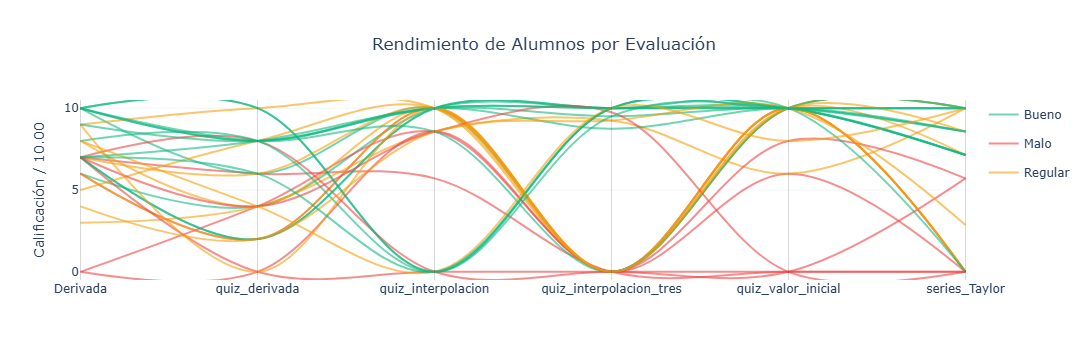

In [5]:
 

df_final[['Clasificacion', 'Color']] = df_final.apply(lambda row: pd.Series(clasificar_alumno(row['Promedio'])), axis=1)

fig1 = go.Figure()

leyendas_agregadas = {'Bueno': False, 'Regular': False, 'Malo': False}

for index, row in df_final.iterrows():
    categoria_actual = row['Clasificacion']
    
    mostrar_leyenda = not leyendas_agregadas[categoria_actual]
    if mostrar_leyenda:
        leyendas_agregadas[categoria_actual] = True

    fig1.add_trace(go.Scatter(
        x=categorias_tests,
        y=row[categorias_tests],
        mode='lines',
        line=dict(color=row['Color'], width=2, shape='spline'),
        opacity=0.6,
        name=categoria_actual, 
        legendgroup=categoria_actual, 
        showlegend=mostrar_leyenda,
        text=[f"<b>{row['Nombre Completo']}</b><br>Promedio: {row['Promedio']:.2f}<br>Clasificación: {row['Clasificacion']}"] * len(categorias_tests),
        hovertemplate="%{text}<br>%{x}: %{y:.2f}<extra></extra>"
    ))

for cat in categorias_tests:
    fig1.add_vline(x=cat, line_width=1, line_dash="solid", line_color="black", opacity=0.15)

fig1.update_layout(
    title='Rendimiento de Alumnos por Evaluación',
    title_x=0.5,
    yaxis=dict(
        title='Calificación / 10.00',
        range=[-0.5, 10.5], 
        gridcolor='rgba(200, 200, 200, 0.2)'
    ),
    plot_bgcolor='white',
    hovermode='closest'
)

fig1.show()

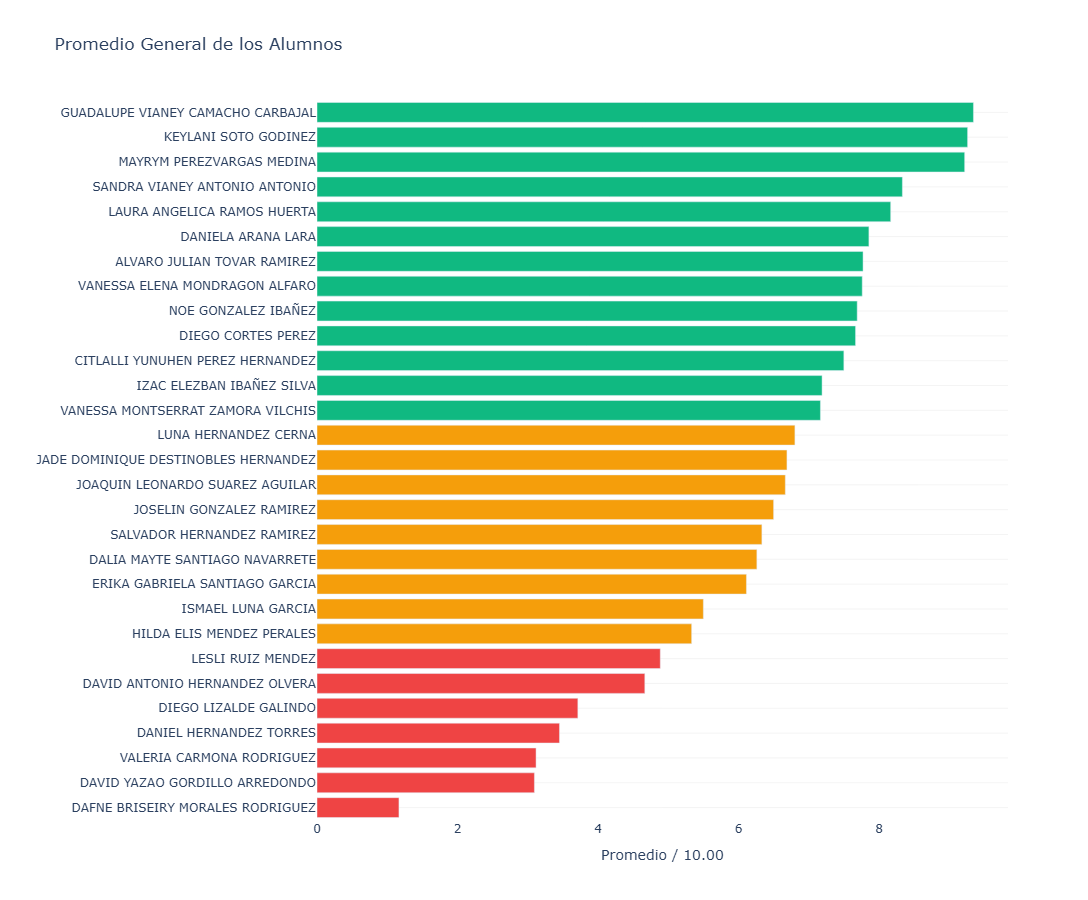

In [6]:
df_promedio = df_final.sort_values(by='Promedio', ascending=True).copy()
colores_promedio = df_promedio['Promedio'].apply(lambda x: clasificar_alumno(x)[1])

fig5 = go.Figure(go.Bar(
    x=df_promedio['Promedio'],
    y=df_promedio['Nombre Completo'],
    orientation='h',
    marker_color=colores_promedio
))

fig5.update_layout(
    title='Promedio General de los Alumnos',
    xaxis_title='Promedio / 10.00',
    yaxis_title='',
    height=900,
    plot_bgcolor='white',
    yaxis=dict(gridcolor='rgba(200, 200, 200, 0.2)')
)

fig5.show()

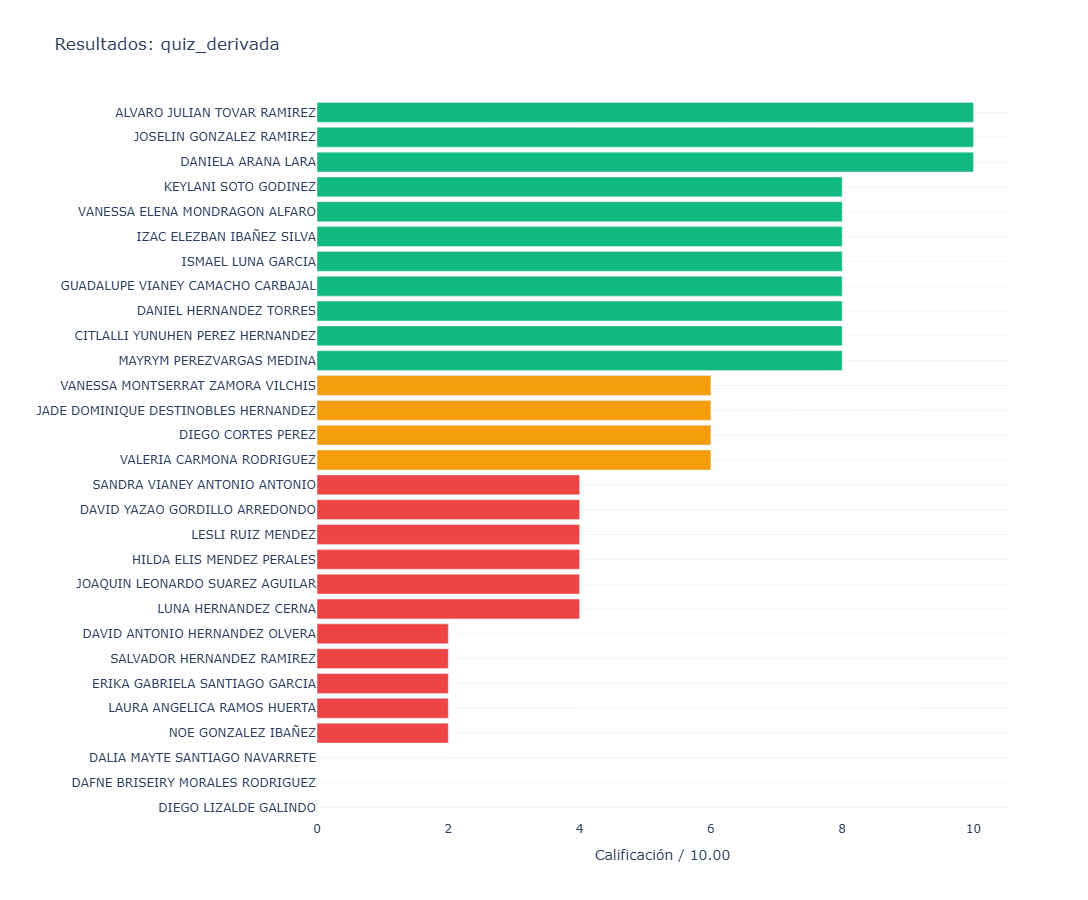

In [7]:
df_1 = df_final.sort_values(by='quiz_derivada', ascending=True).copy()
colores_1 = df_1['quiz_derivada'].apply(lambda x: clasificar_alumno(x)[1])

fig2 = go.Figure(go.Bar(
    x=df_1['quiz_derivada'],
    y=df_1['Nombre Completo'],
    orientation='h',
    marker_color=colores_1
))

fig2.update_layout(
    title='Resultados: quiz_derivada',
    xaxis_title='Calificación / 10.00',
    yaxis_title='',
    height=900,
    plot_bgcolor='white',
    yaxis=dict(gridcolor='rgba(200, 200, 200, 0.2)')
)

fig2.show()


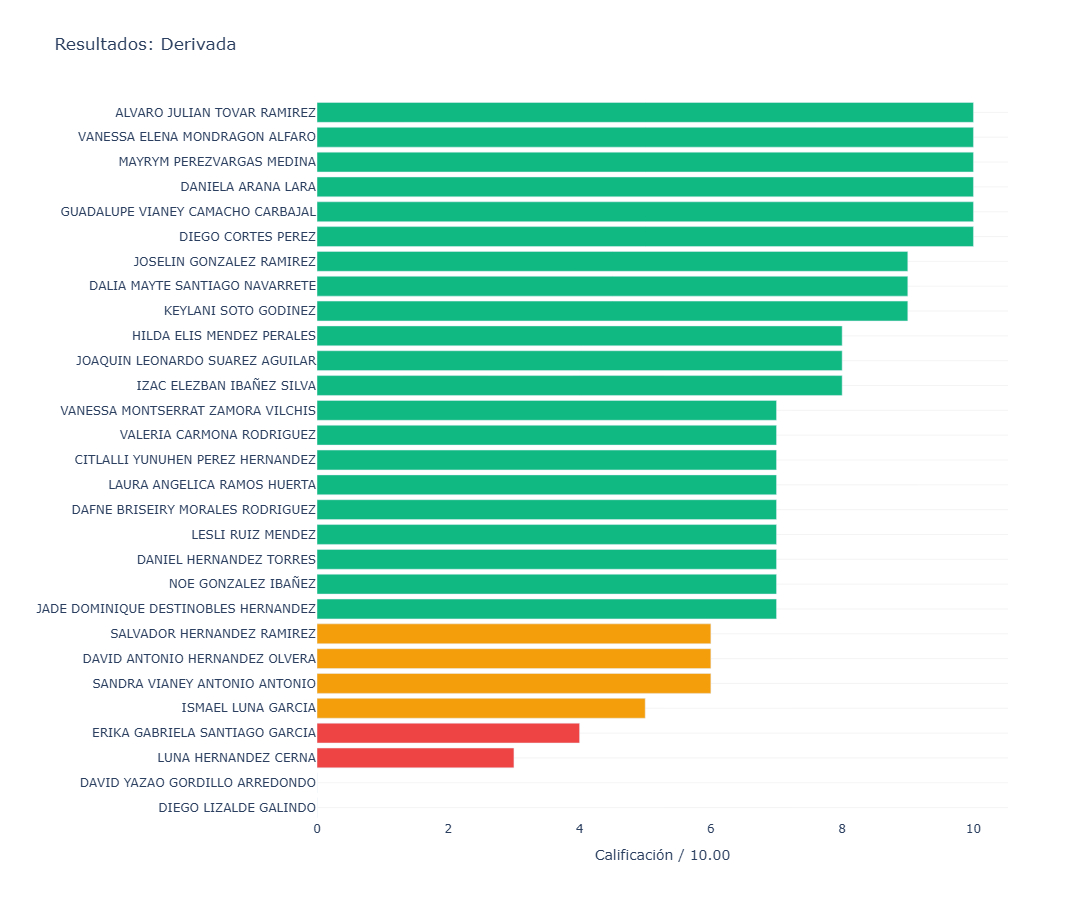

In [8]:
df_2 = df_final.sort_values(by='Derivada', ascending=True).copy()
colores_2 = df_2['Derivada'].apply(lambda x: clasificar_alumno(x)[1])

fig3 = go.Figure(go.Bar(
    x=df_2['Derivada'],
    y=df_2['Nombre Completo'],
    orientation='h',
    marker_color=colores_2
))

fig3.update_layout(
    title='Resultados: Derivada',
    xaxis_title='Calificación / 10.00',
    yaxis_title='',
    height=900,
    plot_bgcolor='white',
    yaxis=dict(gridcolor='rgba(200, 200, 200, 0.2)')
)

fig3.show()

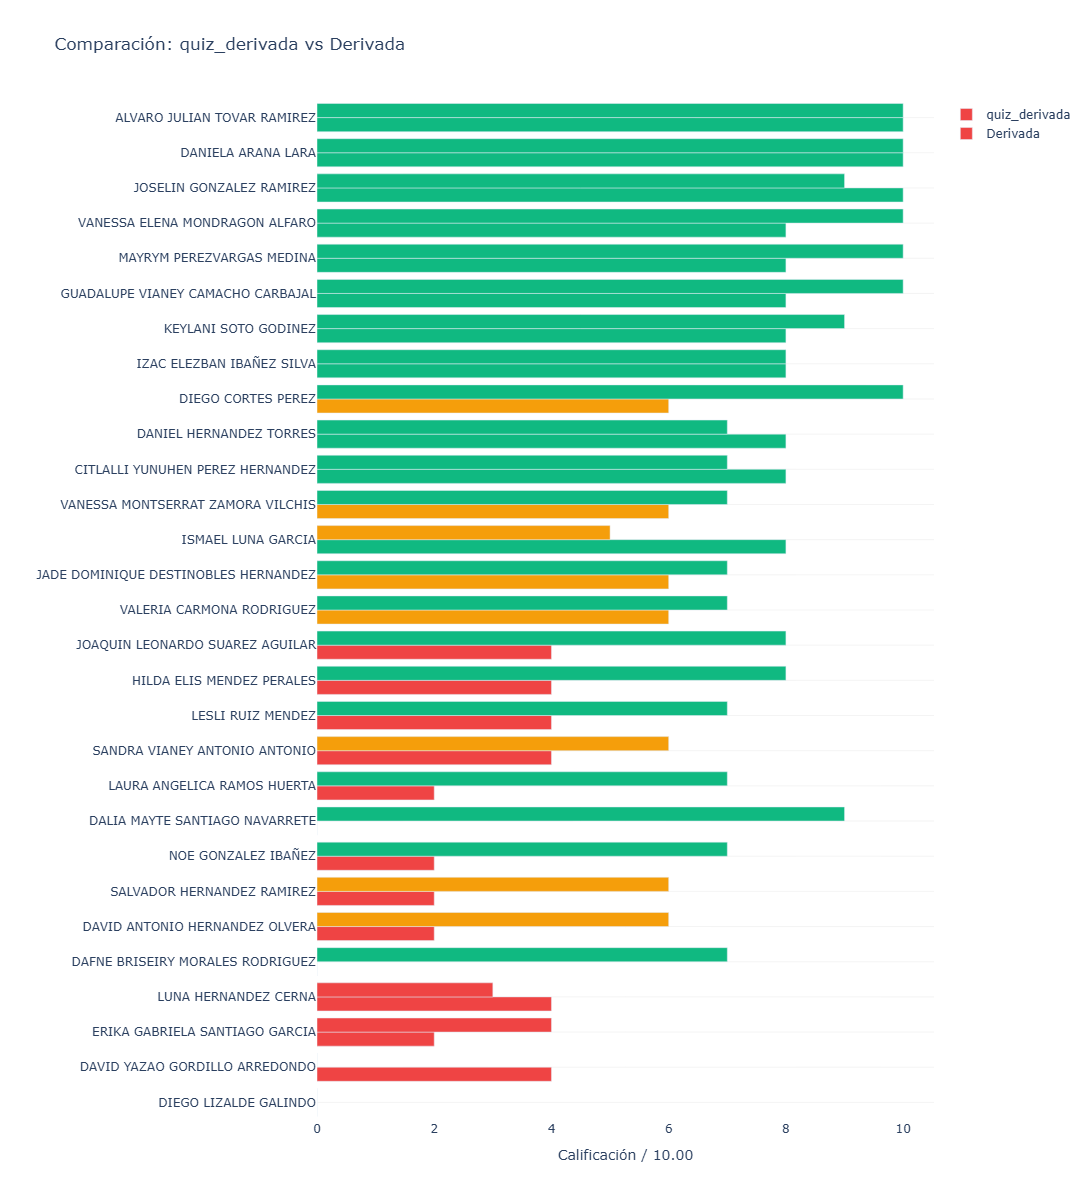

In [9]:
df_3 = df_final.copy()
df_3['suma_temporal'] = df_3['quiz_derivada'] + df_3['Derivada']
df_3 = df_3.sort_values(by='suma_temporal', ascending=True)

colores_quiz = df_3['quiz_derivada'].apply(lambda x: clasificar_alumno(x)[1])
colores_derivada = df_3['Derivada'].apply(lambda x: clasificar_alumno(x)[1])
<z
fig4 = go.Figure()

fig4.add_trace(go.Bar(
    x=df_3['quiz_derivada'],
    y=df_3['Nombre Completo'],
    name='quiz_derivada',
    orientation='h',
    marker_color=colores_quiz
))

fig4.add_trace(go.Bar(
    x=df_3['Derivada'],
    y=df_3['Nombre Completo'],
    name='Derivada',
    orientation='h',
    marker_color=colores_derivada
))

fig4.update_layout(
    title='Comparación: quiz_derivada vs Derivada',
    xaxis_title='Calificación / 10.00',
    yaxis_title='',
    barmode='group',
    height=1200,
    plot_bgcolor='white',
    yaxis=dict(gridcolor='rgba(200, 200, 200, 0.2)')
)

fig4.show()

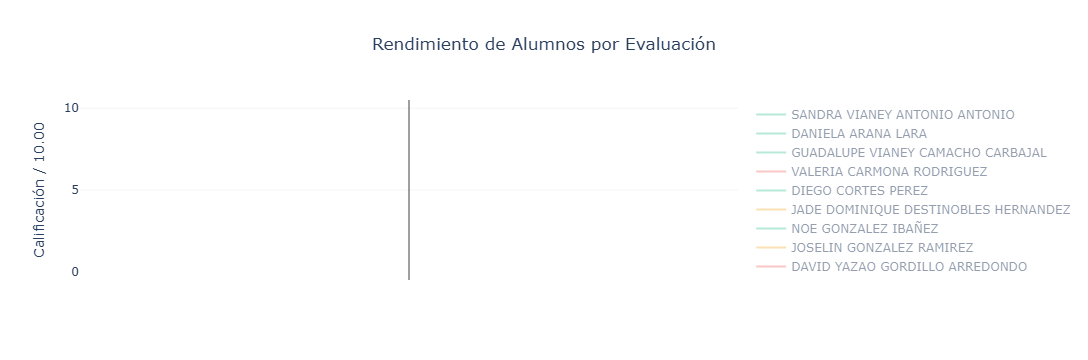

In [10]:


df_final[['Clasificacion', 'Color']] = df_final.apply(lambda row: pd.Series(clasificar_alumno(row['Promedio'])), axis=1)

fig = go.Figure()

for index, row in df_final.iterrows():
    fig.add_trace(go.Scatter(
        x=categorias_tests,
        y=row[categorias_tests],
        mode='lines',
        line=dict(color=row['Color'], width=2, shape='spline'),
        opacity=0.6,
        name=row['Nombre Completo'],
        visible='legendonly',
        text=[f"<b>{row['Nombre Completo']}</b><br>Promedio: {row['Promedio']:.2f}<br>Clasificación: {row['Clasificacion']}"] * len(categorias_tests),
        hovertemplate="%{text}<br>%{x}: %{y:.2f}<extra></extra>"
    ))

for cat in categorias_tests:
    fig.add_vline(x=cat, line_width=1, line_dash="solid", line_color="black", opacity=0.15)

fig.update_layout(
    title='Rendimiento de Alumnos por Evaluación',
    title_x=0.5,
    yaxis=dict(
        title='Calificación / 10.00',
        range=[-0.5, 10.5],
        gridcolor='rgba(200, 200, 200, 0.2)'
    ),
    plot_bgcolor='white',
    hovermode='closest'
)

fig.show()

In [11]:


def clasificar_alumno_dinamico(valor):
    if pd.isna(valor):
        return 'Sin Datos', 'grey'
    elif valor >= 7.0:
        return 'Bueno', 'green'
    elif valor >= 5.0:
        return 'Regular', 'yellow'
    else:
        return 'Malo', 'red'

checkboxes_tests = [widgets.Checkbox(value=True, description=test) for test in categorias_tests]
caja_tests = widgets.HBox(checkboxes_tests, layout=widgets.Layout(flex_flow='row wrap', margin='0 0 20px 0'))

out = widgets.Output()

def actualizar_grafica(*args):
    with out:
        out.clear_output(wait=True)
        
        tests_seleccionados = [cb.description for cb in checkboxes_tests if cb.value]
        
        if not tests_seleccionados:
            print("Selecciona al menos una evaluación.")
            return

        fig = go.Figure()

        for index, row in df_final.iterrows():
            promedio_temp = row[tests_seleccionados].mean()
            clase_temp, color_temp = clasificar_alumno_dinamico(promedio_temp)
            
            fig.add_trace(go.Scatter(
                x=tests_seleccionados,
                y=row[tests_seleccionados],
                mode='lines',
                line=dict(color=color_temp, width=2, shape='spline'),
                opacity=0.6,
                name=row['Nombre Completo'],
                visible='legendonly',
                text=[f"<b>{row['Nombre Completo']}</b><br>Promedio: {promedio_temp:.2f}<br>Clasificación: {clase_temp}"] * len(tests_seleccionados),
                hovertemplate="%{text}<br>%{x}: %{y:.2f}<extra></extra>"
            ))

        for cat in tests_seleccionados:
            fig.add_vline(x=cat, line_width=1, line_dash="solid", line_color="black", opacity=0.15)

        fig.update_layout(
            title='Rendimiento de Alumnos por Evaluación',
            title_x=0.5,
            yaxis=dict(
                title='Calificación / 10.00',
                range=[-0.5, 10.5],
                gridcolor='rgba(200, 200, 200, 0.2)'
            ),
            plot_bgcolor='white',
            hovermode='closest'
        )
        
        fig.show()

for cb in checkboxes_tests:
    cb.observe(actualizar_grafica, names='value')

actualizar_grafica()

display(widgets.VBox([caja_tests, out]))

In [13]:
import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

dropdown = widgets.Dropdown(options=categorias_tests + ['Promedio'], value='Promedio', description='Evaluación:')
out_gauss = widgets.Output()

def actualizar_campana(*args):
    with out_gauss:
        out_gauss.clear_output(wait=True)
        datos = df_final[dropdown.value]
        
        bins = np.arange(0, 10.5, 0.5)
        frecuencias, bordes = np.histogram(datos, bins=bins)
        
        colores = ['green' if x >= 7.0 else 'yellow' if x >= 5.0 else 'red' for x in bordes[:-1]]
        
        fig = go.Figure()
        
        fig.add_trace(go.Bar(
            x=bordes[:-1] + 0.25,
            y=frecuencias,
            width=0.45,
            marker_color=colores,
            name='Alumnos'
        ))
        
        mu = datos.mean()
        sigma = datos.std()
        
        if sigma > 0:
            x_curva = np.linspace(0, 10, 100)
            y_curva = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_curva - mu) / sigma) ** 2)
            y_escalado = y_curva * len(datos) * 0.5
            
            fig.add_trace(go.Scatter(
                x=x_curva,
                y=y_escalado,
                mode='lines',
                line=dict(color='black', width=3, shape='spline'),
                name='Campana'
            ))
        
        fig.update_layout(
            title=f'{dropdown.value} | Media: {mu:.2f} | Desviación: {sigma:.2f}',
            xaxis=dict(title='Calificación', range=[0, 10], dtick=0.5),
            yaxis=dict(title='Número de Alumnos'),
            plot_bgcolor='white',
            showlegend=False
        )
        
        fig.show()

dropdown.observe(actualizar_campana, names='value')
actualizar_campana()

display(widgets.VBox([dropdown, out_gauss]))